In [5]:
import re, pandas as pd, numpy as np
import plotly.graph_objects as go
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from pathlib import Path
from IPython.display import display

In [10]:
BASE_DIR = Path("/Users/elipieri/repos/SeamStress")

DATASETS = {
    "ethylene":     "Ethylene",
    "butadiene_s0": "Butadiene S₀/S₁",
    "butadiene_s1": "Butadiene S₁/S₂",
    "benzene_s0":   "Benzene S₀/S₁",
    "benzene_s1":   "Benzene S₁/S₂",
}

# ── Custom MECI display names ─────────────────────────────────────────────────
# Keys are the normalised names as they appear in correspondence.csv
# (lowercase, underscores kept). Leave empty to use auto-renaming.
MECI_NAMES = {
    "ethylene": {
        "cc_dissociation":       "CC Diss.",
        "ch_dissociation":       "CH Diss.",
        "ethylidene_bent":       "Ethylidene Bent",
        "ethylidene_straight":   "Ethylidene Straight",
        "h_dissociation":        "H Diss.",
        "h_dissociation_ethylidene": "H Diss. (Eth.)",
        "hh_dissociation":       r"$H_2$ Diss.",
        "tilted_saddle":         "Tilted Saddle",
        "twist":                 "Twist",
    },
    "butadiene_s0": {},
    "butadiene_s1": {},
    "benzene_s0": {
        "double_h": "H Migration",
    },
    "benzene_s1": {},
}

# ── Node colours ──────────────────────────────────────────────────────────────
COLOR_BASIN = "steelblue"
COLOR_ALIGN = "mediumpurple"
COLOR_CSV   = "salmon"

# ── Link colours ─────────────────────────────────────────────────────────────
COLOR_LINK_BA = "rgba(70,130,180,0.4)"
COLOR_LINK_AC = "rgba(180,100,180,0.4)"

# ── Output ────────────────────────────────────────────────────────────────────
SAVE_PNG = True
SAVE_SVG = True
OUT_DIR  = BASE_DIR / "seam_basin"
FIG_WIDTH  = 1050
FIG_HEIGHT = 620
FIG_SCALE  = 3

In [11]:
def auto_display_name(raw):
    '''Convert type1/Type_1/type_1 etc. to "Type 1"; otherwise return as-is.'''
    m = re.match(r'^[Tt]ype_?(\d+)$', str(raw))
    if m:
        return f"Type {m.group(1)}"
    return raw


def display_name(raw, custom):
    '''Look up custom name, fall back to auto_display_name.'''
    if raw in custom:
        return custom[raw]
    return auto_display_name(raw)


def make_sankey(ds, label):
    df = pd.read_csv(BASE_DIR / "seam_basin" / ds / "correspondence.csv", index_col=0)
    df = df.dropna(subset=["csv_meci"])
    custom = MECI_NAMES.get(ds, {})

    ari_ba = adjusted_rand_score(df["basin_id"], df["align_meci"])
    nmi_ba = normalized_mutual_info_score(df["basin_id"].astype(str), df["align_meci"])
    ari_ac = adjusted_rand_score(df["align_meci"], df["csv_meci"])
    nmi_ac = normalized_mutual_info_score(df["align_meci"], df["csv_meci"])

    basins     = sorted(df["basin_id"].unique())
    align_mecs = sorted(df["align_meci"].unique())
    csv_mecs   = sorted(df["csv_meci"].unique())

    # 1-indexed basin labels
    basin_labels = [f"Basin {b+1}" for b in range(len(basins))]
    align_labels = [display_name(m, custom) for m in align_mecs]
    csv_labels   = [display_name(m, custom) for m in csv_mecs]

    basin_idx = {b: i                             for i, b in enumerate(basins)}
    align_idx = {m: len(basins) + i               for i, m in enumerate(align_mecs)}
    csv_idx   = {m: len(basins)+len(align_mecs)+i for i, m in enumerate(csv_mecs)}

    node_labels = basin_labels + align_labels + csv_labels
    node_colors = ([COLOR_BASIN] * len(basins) +
                   [COLOR_ALIGN] * len(align_mecs) +
                   [COLOR_CSV]   * len(csv_mecs))

    src1, tgt1, val1 = [], [], []
    for (b, m), grp in df.groupby(["basin_id", "align_meci"]):
        src1.append(basin_idx[b]); tgt1.append(align_idx[m]); val1.append(len(grp))

    src2, tgt2, val2 = [], [], []
    for (am, cm), grp in df.groupby(["align_meci", "csv_meci"]):
        src2.append(align_idx[am]); tgt2.append(csv_idx[cm]); val2.append(len(grp))

    link_colors = ([COLOR_LINK_BA] * len(src1) +
                   [COLOR_LINK_AC] * len(src2))

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=node_labels, color=node_colors, pad=14, thickness=18),
        link=dict(source=src1+src2, target=tgt1+tgt2, value=val1+val2, color=link_colors),
    ))
    fig.update_layout(
        title=dict(
            text=(
                f"{label}  —  Basin → Alignment MECI → CSV MECI  (flow = # spawns)<br>"
                f"<sup>"
                f"Basin ↔ Alignment:  ARI = {ari_ba:.3f},  NMI = {nmi_ba:.3f}"
                f"&nbsp;&nbsp;| &nbsp;"
                f"Alignment ↔ CSV:  ARI = {ari_ac:.3f},  NMI = {nmi_ac:.3f}"
                f"</sup>"
            ),
            font=dict(size=14),
        ),
        font_size=12, height=FIG_HEIGHT, width=FIG_WIDTH,
    )
    return fig

def make_sankey_2col(ds, label):
    df = pd.read_csv(BASE_DIR / "seam_basin" / ds / "correspondence.csv", index_col=0)
    df = df.dropna(subset=["csv_meci"])
    custom = MECI_NAMES.get(ds, {})

    ari = adjusted_rand_score(df["basin_id"].astype(str), df["csv_meci"])
    nmi = normalized_mutual_info_score(df["basin_id"].astype(str), df["csv_meci"])

    basins   = sorted(df["basin_id"].unique())
    csv_mecs = sorted(df["csv_meci"].unique())

    basin_labels = [f"Basin {b+1}" for b in range(len(basins))]
    csv_labels   = [display_name(m, custom) for m in csv_mecs]

    basin_idx = {b: i                   for i, b in enumerate(basins)}
    csv_idx   = {m: len(basins) + i     for i, m in enumerate(csv_mecs)}

    node_labels = basin_labels + csv_labels
    node_colors = [COLOR_BASIN] * len(basins) + [COLOR_CSV] * len(csv_mecs)

    src, tgt, val = [], [], []
    for (b, cm), grp in df.groupby(["basin_id", "csv_meci"]):
        src.append(basin_idx[b]); tgt.append(csv_idx[cm]); val.append(len(grp))

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=node_labels, color=node_colors, pad=14, thickness=18),
        link=dict(source=src, target=tgt, value=val, color=COLOR_LINK_BA),
    ))
    fig.update_layout(
        title=dict(
            text=(
                f"{label}  —  Basin → CSV MECI  (flow = # spawns)<br>"
                f"<sup>ARI = {ari:.3f},  NMI = {nmi:.3f}</sup>"
            ),
            font=dict(size=14),
        ),
        font_size=12, height=FIG_HEIGHT, width=FIG_WIDTH,
    )
    return fig

def make_sankey_basin_align(ds, label):
    df = pd.read_csv(BASE_DIR / "seam_basin" / ds / "correspondence.csv", index_col=0)
    df = df.dropna(subset=["csv_meci"])
    custom = MECI_NAMES.get(ds, {})

    ari = adjusted_rand_score(df["basin_id"].astype(str), df["align_meci"])
    nmi = normalized_mutual_info_score(df["basin_id"].astype(str), df["align_meci"])

    basins     = sorted(df["basin_id"].unique())
    align_mecs = sorted(df["align_meci"].unique())

    basin_labels = [f"Basin {b+1}" for b in range(len(basins))]
    align_labels = [display_name(m, custom) for m in align_mecs]

    basin_idx = {b: i                 for i, b in enumerate(basins)}
    align_idx = {m: len(basins) + i   for i, m in enumerate(align_mecs)}

    node_labels = basin_labels + align_labels
    node_colors = [COLOR_BASIN] * len(basins) + [COLOR_ALIGN] * len(align_mecs)

    src, tgt, val = [], [], []
    for (b, m), grp in df.groupby(["basin_id", "align_meci"]):
        src.append(basin_idx[b]); tgt.append(align_idx[m]); val.append(len(grp))

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=node_labels, color=node_colors, pad=14, thickness=18),
        link=dict(source=src, target=tgt, value=val, color=COLOR_LINK_BA),
    ))
    fig.update_layout(
        title=dict(
            text=(
                f"{label}  —  Basin → Alignment MECI  (flow = # spawns)<br>"
                f"<sup>ARI = {ari:.3f},  NMI = {nmi:.3f}</sup>"
            ),
            font=dict(size=14),
        ),
        font_size=12, height=FIG_HEIGHT, width=FIG_WIDTH,
    )
    return fig

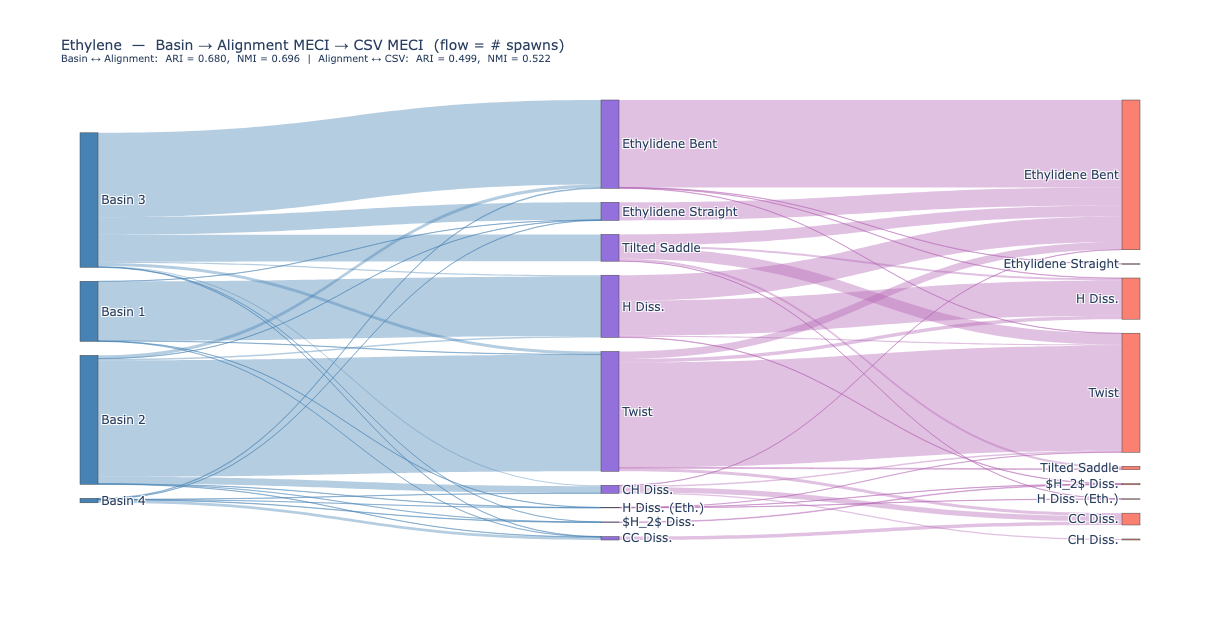

/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:6: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.png"), scale=FIG_SCALE)
/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:8: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.svg"), scale=FIG_SCALE)


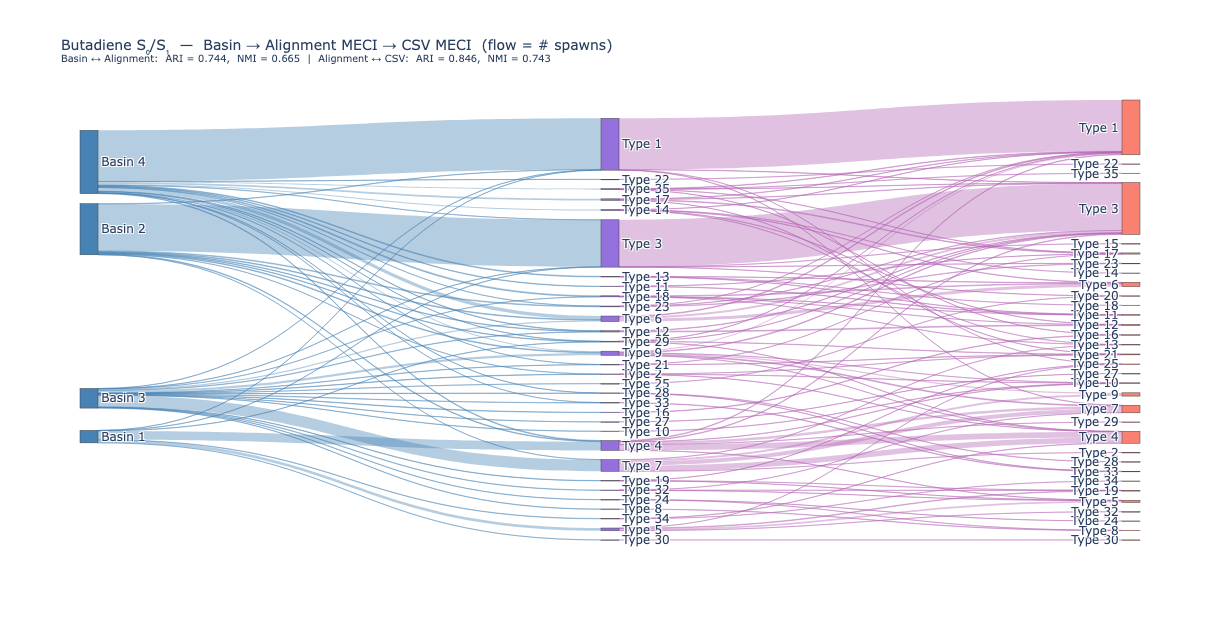

/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:6: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.png"), scale=FIG_SCALE)
/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:8: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.svg"), scale=FIG_SCALE)


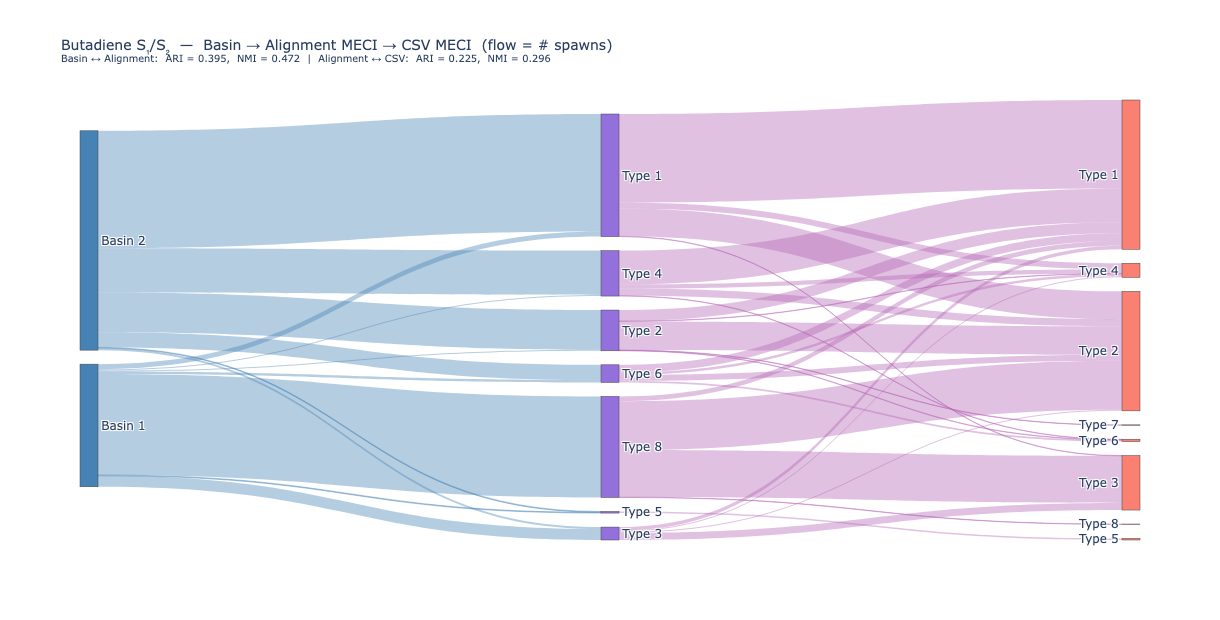

/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:6: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.png"), scale=FIG_SCALE)
/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:8: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.svg"), scale=FIG_SCALE)


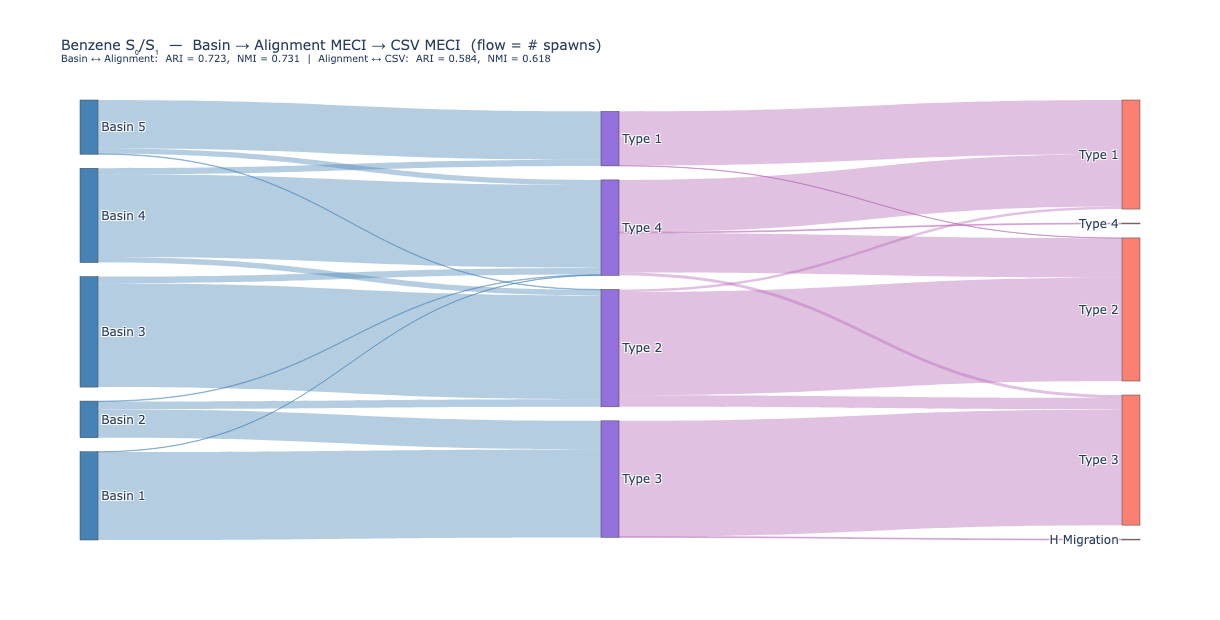

/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:6: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.png"), scale=FIG_SCALE)
/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:8: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.svg"), scale=FIG_SCALE)


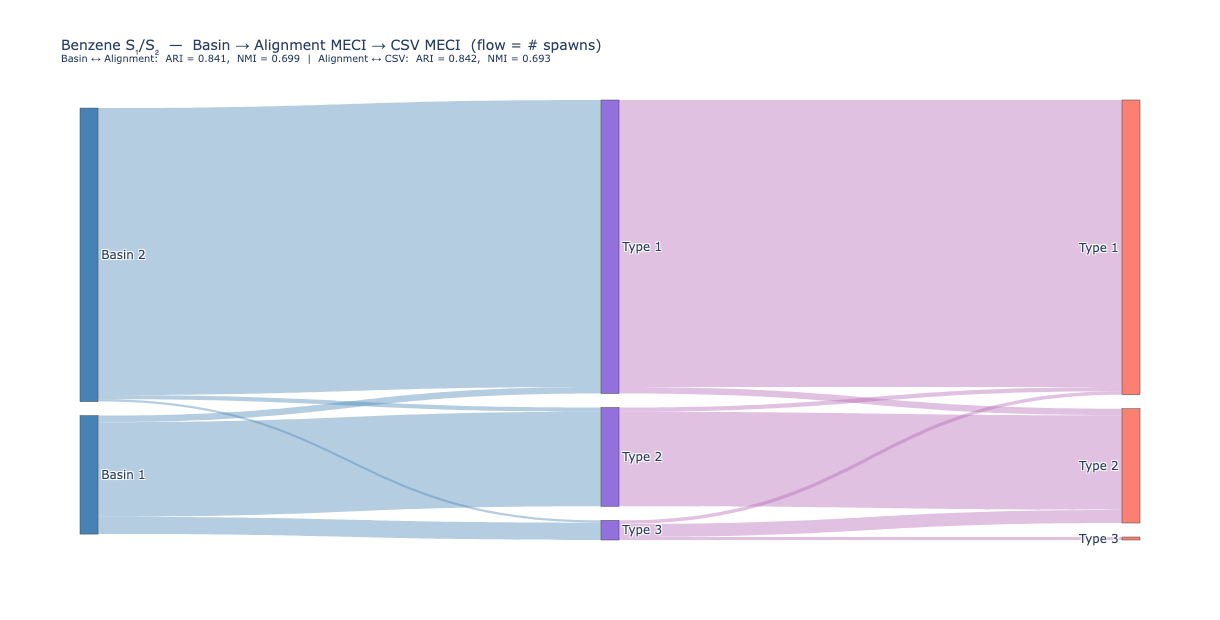

/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:6: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.png"), scale=FIG_SCALE)
/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_56016/112223800.py:8: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.svg"), scale=FIG_SCALE)


In [12]:
for ds, label in DATASETS.items():
    fig = make_sankey(ds, label)
    display(fig)
    safe = ds
    if SAVE_PNG:
        fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.png"), scale=FIG_SCALE)
    if SAVE_SVG:
        fig.write_image(str(OUT_DIR / f"viz_sankey3_{safe}.svg"), scale=FIG_SCALE)

In [ ]:
for ds, label in DATASETS.items():
    fig = make_sankey_2col(ds, label)
    display(fig)
    safe = ds
    if SAVE_PNG:
        fig.write_image(str(OUT_DIR / f"viz_sankey2_{safe}.png"), scale=FIG_SCALE, dpi=300)
    if SAVE_SVG:
        fig.write_image(str(OUT_DIR / f"viz_sankey2_{safe}.svg"), scale=FIG_SCALE, dpi=300)

In [ ]:
for ds, label in DATASETS.items():
    fig = make_sankey_basin_align(ds, label)
    display(fig)
    safe = ds
    if SAVE_PNG:
        fig.write_image(str(OUT_DIR / f"viz_sankey2_align_{safe}.png"), scale=FIG_SCALE, dpi=300)
    if SAVE_SVG:
        fig.write_image(str(OUT_DIR / f"viz_sankey2_align_{safe}.svg"), scale=FIG_SCALE, dpi=300)